# ML-Based Exit Signals: Two-Model Architecture
**Docker image**: `ml4t`

## Purpose
Demonstrate a two-model exit architecture in which entry-model confidence becomes an
explicit feature of the exit model, and judge the resulting decision rule against a
basic exit baseline using both AUC and realized trade-path metrics.

## Learning Objectives
After completing this notebook, you will be able to:
- Train separate entry and exit prediction models on a shared feature set.
- Inject entry-probability into the exit model and read its feature importance.
- Evaluate exit logic by AUC *and* by realized trade-path metrics, not AUC alone.
- Recognize when an architectural change does not pay off on AUC but still matters operationally.

## Book reference
§19.7 Adaptive Risk Controls — Figure 19.5 (signal-strength-conditioned barrier outcomes).

## Prerequisites
Complete [`02_exit_strategies`](02_exit_strategies.ipynb) first for the rule-based exit
baseline (fixed stops, trailing stops, volatility-adjusted exits, whipsaw analysis) that
this notebook extends with an ML-driven exit policy.

## Setup

In [1]:
"""ML-Based Exit Signals — train a two-model architecture where entry confidence drives exit timing."""

import warnings
from datetime import UTC, datetime

import lightgbm as lgb
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from matplotlib import pyplot as plt
from plotly.subplots import make_subplots
from sklearn.metrics import roc_auc_score

from data import load_crypto_perps
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0
SEED = 42

In [3]:
np.random.seed(SEED)
OUTPUT_DIR = get_output_dir(19, "ml_exit_signals")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
set_global_seeds(SEED)

## 1. Data Loading

Three crypto perpetuals (BTC, ETH, SOL) at hourly frequency from 2023-01-01. High
volatility and round-the-clock trading make exit timing the dominant risk control
rather than a corner-case concern.

In [5]:
ohlcv = load_crypto_perps(frequency="1h")

SYMBOLS = ["BTCUSDT", "ETHUSDT", "SOLUSDT"]
START_DATE = "2023-01-01"

# Filter data
timestamp_dtype = ohlcv.schema["timestamp"]
start_ts = datetime.fromisoformat(f"{START_DATE}T00:00:00")
if getattr(timestamp_dtype, "time_zone", None):
    start_ts = start_ts.replace(tzinfo=UTC)

df = ohlcv.filter(
    (pl.col("symbol").is_in(SYMBOLS))
    & (pl.col("timestamp") >= pl.lit(start_ts, dtype=timestamp_dtype))
)

print(f"Loaded {len(df):,} rows for {df['symbol'].n_unique()} symbols")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Loaded 78,912 rows for 3 symbols
Date range: 2023-01-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00


**Interpretation**: The sample is intentionally short-horizon and volatile, so the
exit model has enough adverse moves to learn from. That makes crypto perpetuals a
good stress test for conviction-driven exits.

## 2. Feature Engineering

Create technical features for both entry and exit models.

The feature builder combines momentum, volatility, mean-reversion, and volume
signals into a single tabular dataset for both the entry and exit models.

In [6]:
def create_features(df: pl.DataFrame, forward_hours: int = 24) -> pl.DataFrame:
    """
    Create features for entry/exit models.

    Features focus on momentum, volatility, and mean reversion signals.
    """
    close = pl.col("close")
    returns = close.pct_change()
    feature_exprs = [
        returns.over("symbol").alias("ret_1h"),
        close.pct_change(4).over("symbol").alias("ret_4h"),
        close.pct_change(8).over("symbol").alias("ret_8h"),
        close.pct_change(24).over("symbol").alias("ret_24h"),
        close.pct_change(72).over("symbol").alias("ret_72h"),
        returns.rolling_std(24).over("symbol").alias("vol_24h"),
        returns.rolling_std(72).over("symbol").alias("vol_72h"),
        (
            returns.rolling_mean(14).over("symbol") / returns.abs().rolling_mean(14).over("symbol")
        ).alias("rsi_proxy"),
        (close / close.rolling_mean(24).over("symbol") - 1).alias("dist_ma24"),
        (close / close.rolling_mean(72).over("symbol") - 1).alias("dist_ma72"),
        (pl.col("volume") / pl.col("volume").rolling_mean(24).over("symbol")).alias("vol_ratio"),
        ((pl.col("high") - pl.col("low")) / close).alias("hl_range"),
        (((pl.col("high") - pl.col("low")) / close).rolling_mean(24).over("symbol")).alias(
            "hl_range_ma"
        ),
        close.pct_change(forward_hours).shift(-forward_hours).over("symbol").alias("fwd_return"),
        # True one-step realized return: close[t] -> close[t+1], per symbol.
        # Used for the trade-path backtest so realized PnL is summed from
        # actual next-bar returns rather than a forward label divided by h.
        close.pct_change().shift(-1).over("symbol").alias("realized_ret_1step"),
    ]
    return df.sort(["symbol", "timestamp"]).with_columns(feature_exprs).drop_nulls()

In [7]:
# Create features
df_feat = create_features(df, forward_hours=24)

# Define feature columns
FEATURE_COLS = [
    "ret_1h",
    "ret_4h",
    "ret_8h",
    "ret_24h",
    "ret_72h",
    "vol_24h",
    "vol_72h",
    "rsi_proxy",
    "dist_ma24",
    "dist_ma72",
    "vol_ratio",
    "hl_range",
    "hl_range_ma",
]

print(f"Feature dataset: {len(df_feat):,} samples")
print("Forward return stats:")
print(f"  Mean:   {df_feat['fwd_return'].mean():.4%}")
print(f"  Std:    {df_feat['fwd_return'].std():.4%}")
print(f"  5th:    {df_feat['fwd_return'].quantile(0.05):.4%}")
print(f"  95th:   {df_feat['fwd_return'].quantile(0.95):.4%}")

Feature dataset: 78,624 samples
Forward return stats:
  Mean:   0.2093%
  Std:    3.6036%
  5th:    -5.1950%
  95th:   6.0672%


**Interpretation**: The forward-return distribution is heavy enough in both tails to
justify separate entry and exit labels. A symmetric Gaussian world would not make
the exit model especially useful.

## 3. Label Creation

**Entry Label**: Top 5% returns (exceptional opportunities)
**Exit Label**: Negative returns (should exit to avoid loss)

In [8]:
# Calculate thresholds
top_5pct_threshold = df_feat["fwd_return"].quantile(0.95)

# Create labels
df_labeled = df_feat.with_columns(
    [
        # Entry: top 5% returns
        (pl.col("fwd_return") >= top_5pct_threshold).cast(pl.Int8).alias("y_entry"),
        # Exit: negative returns
        (pl.col("fwd_return") < 0).cast(pl.Int8).alias("y_exit"),
    ]
)

print("\nLabel Distribution:")
print(f"  Entry (top 5%):     {df_labeled['y_entry'].mean():.1%} positive")
print(f"  Exit (negative):    {df_labeled['y_exit'].mean():.1%} positive")
print(f"  Top 5% threshold:   {top_5pct_threshold:.2%}")


Label Distribution:
  Entry (top 5%):     5.0% positive
  Exit (negative):    48.7% positive
  Top 5% threshold:   6.07%


**Interpretation**: The label split is intentionally asymmetric. Entry targets rare
high-payoff opportunities, while exit targets the much larger set of adverse moves.

## 4. Train/Test Split

Time-series aware split - no future leakage.

In [9]:
# Convert to pandas for sklearn
df_pd = df_labeled.select(
    ["timestamp", "symbol"]
    + FEATURE_COLS
    + ["y_entry", "y_exit", "fwd_return", "realized_ret_1step"]
).to_pandas()

# Time-based split on a timestamp cutoff (not row position). df_labeled is
# sorted by (symbol, timestamp), so a positional iloc split would be a
# symbol split — most assets entirely in train, a few entirely in test.
# A timestamp cutoff gives a genuine cross-sectional time split.
cutoff_ts = df_pd["timestamp"].quantile(0.8)
train_df = df_pd[df_pd["timestamp"] <= cutoff_ts].sort_values(["timestamp", "symbol"])
test_df = df_pd[df_pd["timestamp"] > cutoff_ts].sort_values(["timestamp", "symbol"])

X_train = train_df[FEATURE_COLS].values
X_test = test_df[FEATURE_COLS].values

y_entry_train = train_df["y_entry"].values
y_entry_test = test_df["y_entry"].values

y_exit_train = train_df["y_exit"].values
y_exit_test = test_df["y_exit"].values

print(
    f"Train: {len(X_train):,} samples ({train_df['timestamp'].min()} to {train_df['timestamp'].max()})"
)
print(
    f"Test:  {len(X_test):,} samples ({test_df['timestamp'].min()} to {test_df['timestamp'].max()})"
)

Train: 62,901 samples (2023-01-04 00:00:00+00:00 to 2025-05-26 14:00:00+00:00)
Test:  15,723 samples (2025-05-26 15:00:00+00:00 to 2025-12-30 23:00:00+00:00)


**Interpretation**: The chronological split keeps the exit architecture honest.
Entry-model probabilities are generated on past data only, so the enhanced exit
model cannot borrow future information through the feedback loop.

## 5. Train Entry Model

Predicts exceptional positive returns (top 5%).

In [10]:
entry_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=5,
    min_child_samples=20,
    verbosity=-1,
    random_state=42,
)

entry_model.fit(X_train, y_entry_train)

entry_proba_train = entry_model.predict_proba(X_train)[:, 1]
entry_proba_test = entry_model.predict_proba(X_test)[:, 1]

entry_auc = roc_auc_score(y_entry_test, entry_proba_test)
print(f"Entry Model AUC-ROC: {entry_auc:.4f}")

entry_importance = pd.DataFrame(
    {"feature": FEATURE_COLS, "importance": entry_model.feature_importances_}
).sort_values("importance", ascending=False)
entry_importance.head(5).reset_index(drop=True)

Entry Model AUC-ROC: 0.6907


,feature,importance
0,vol_72h,590
1,hl_range_ma,354
2,ret_72h,343
3,vol_24h,316
4,dist_ma72,266


**Interpretation**: The entry model sets the benchmark for conviction. Its AUC and
feature ranking tell us whether the signal has enough structure to be useful as an
input to the exit model.

## 6. Train Exit Model (Basic)

Predicts negative returns using same features.

In [11]:
exit_model_basic = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=5,
    min_child_samples=20,
    verbosity=-1,
    random_state=42,
)

exit_model_basic.fit(X_train, y_exit_train)

exit_proba_basic = exit_model_basic.predict_proba(X_test)[:, 1]

exit_auc_basic = roc_auc_score(y_exit_test, exit_proba_basic)
print(f"Basic Exit Model AUC-ROC: {exit_auc_basic:.4f}")

Basic Exit Model AUC-ROC: 0.4866


**Interpretation**: The basic exit model shows how much adverse-move prediction is
already present in the raw feature set before we feed in entry conviction.

## 7. Train Enhanced Exit Model

Add the entry-model probability as an extra feature. The hypothesis is that fading
conviction is informative about adverse moves on its own — independent of the raw
technicals — so the exit model should be able to exploit it.

In [12]:
# Add entry prediction as feature
X_train_enhanced = np.column_stack([X_train, entry_proba_train])
X_test_enhanced = np.column_stack([X_test, entry_proba_test])

FEATURE_COLS_ENHANCED = FEATURE_COLS + ["entry_prediction"]

exit_model_enhanced = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=5,
    min_child_samples=20,
    verbosity=-1,
    random_state=42,
)

exit_model_enhanced.fit(X_train_enhanced, y_exit_train)

# Predictions
exit_proba_enhanced = exit_model_enhanced.predict_proba(X_test_enhanced)[:, 1]

# Evaluate
exit_auc_enhanced = roc_auc_score(y_exit_test, exit_proba_enhanced)
improvement = (exit_auc_enhanced - exit_auc_basic) / exit_auc_basic * 100

print(f"Enhanced Exit Model AUC-ROC: {exit_auc_enhanced:.4f}")
print(f"AUC delta vs basic:          {improvement:+.2f}%")

enhanced_importance = pd.DataFrame(
    {"feature": FEATURE_COLS_ENHANCED, "importance": exit_model_enhanced.feature_importances_}
).sort_values("importance", ascending=False)
enhanced_importance.head(5).reset_index(drop=True)

Enhanced Exit Model AUC-ROC: 0.4937
AUC delta vs basic:          +1.45%


,feature,importance
0,vol_72h,402
1,ret_72h,347
2,vol_24h,313
3,hl_range_ma,281
4,entry_prediction,257


**Interpretation**: The enhanced AUC barely moves — 0.494 versus the basic
baseline's 0.487 (+1.45%), with both sitting essentially at the 0.5 no-skill
line on this short sample, so AUC cannot meaningfully separate the two models.
Yet `entry_prediction` ends up among the top features, which means the
gradient-boosted exit model *is* using it; whatever the architectural benefit,
AUC at this scale is too coarse to register it. Sections 8–10 weigh that
benefit on realized trades instead, which is where §19.7 tells us to look.

## 8. Model Comparison

The summary table puts the three models on one page so we can judge whether the
extra architecture earns its complexity.

In [13]:
delta_label = f"AUC delta: {improvement:+.2f}%"
comparison_summary = pl.DataFrame(
    {
        "Model": ["Entry (Top 5%)", "Exit (Basic)", "Exit (Enhanced)"],
        "AUC-ROC": [entry_auc, exit_auc_basic, exit_auc_enhanced],
        "Features": [
            "Technical indicators",
            "Technical indicators only",
            "Technical + Entry Prediction",
        ],
        "Notes": [
            "Identify exceptional opportunities",
            "Baseline exit model",
            delta_label,
        ],
    }
)
comparison_summary

Model,AUC-ROC,Features,Notes
str,f64,str,str
"""Entry (Top 5%)""",0.690675,"""Technical indicators""","""Identify exceptional opportuni…"
"""Exit (Basic)""",0.486645,"""Technical indicators only""","""Baseline exit model"""
"""Exit (Enhanced)""",0.493707,"""Technical + Entry Prediction""","""AUC delta: +1.45%"""


**Interpretation**: AUC alone is not the decision rule. On this sample the enhanced
exit model's AUC is a hair *above* the basic baseline (0.494 vs 0.487) but both
sit at the no-skill line, yet `entry_prediction` still ranks among the top
features — the architecture is contributing information that the raw classification
metric is too coarse to reward either way. The §19.7 claim that learned exits
should be judged by *realized trade paths*, not classification scores in isolation,
is the operating principle: Section 10's backtest is the binding evaluation.

## 9. Signal Analysis

How do entry and exit signals interact?

The entry label marks the top 5% of forward returns, so a 0.5 probability
threshold is deliberately severe: it admits only bars where the model is
more confident than not that a rare top-5% move is coming. This is a
sparse-entry policy by design — it trades coverage for precision rather
than trying to be in the market most of the time.

In [14]:
# Create signal thresholds
entry_threshold = 0.5
exit_threshold = 0.5
entry_confidence_drop = 0.3  # Exit if entry confidence drops below this

# Classify signals
entry_signal = entry_proba_test > entry_threshold
exit_signal_model = exit_proba_enhanced > exit_threshold
exit_signal_confidence = entry_proba_test < entry_confidence_drop

# Combined exit: model says exit OR entry confidence too low
exit_signal_combined = exit_signal_model | exit_signal_confidence

In [15]:
signal_counts = pl.DataFrame(
    {
        "Rule": [
            f"Entry signal (p_entry > {entry_threshold})",
            f"Exit model (p_exit > {exit_threshold})",
            f"Confidence drop (p_entry < {entry_confidence_drop})",
            "Combined exit (OR)",
        ],
        "Count": [
            int(entry_signal.sum()),
            int(exit_signal_model.sum()),
            int(exit_signal_confidence.sum()),
            int(exit_signal_combined.sum()),
        ],
        "Share of bars": [
            f"{entry_signal.mean():.1%}",
            f"{exit_signal_model.mean():.1%}",
            f"{exit_signal_confidence.mean():.1%}",
            f"{exit_signal_combined.mean():.1%}",
        ],
    }
)
signal_counts

Rule,Count,Share of bars
str,i64,str
"""Entry signal (p_entry > 0.5)""",4,"""0.0%"""
"""Exit model (p_exit > 0.5)""",6844,"""43.5%"""
"""Confidence drop (p_entry < 0.3…",15691,"""99.8%"""
"""Combined exit (OR)""",15691,"""99.8%"""


**Interpretation**: The confidence-drop clause fires on the overwhelming majority of
bars because entry-probability rarely exceeds 0.3 — the entry label is the top 5% of
returns, so most bars are "not an entry" by construction. As a result, the
combined-OR rule is dominated by the confidence-drop clause and behaves close to
*exit on almost every bar*. This is a calibration problem the chapter flags rather
than a victory: Section 10 measures whether that aggressive exit policy actually
hurts realized P&L.

## 10. Backtest Simulation

Compare exit strategies on actual returns.

The trade recorder keeps the backtest summary compact and makes the exit-reason counts consistent across strategies.

In [16]:
def build_trade(entry_idx: int, exit_idx: int, returns: np.ndarray, exit_reason: str) -> dict:
    """Create a standardized trade record for the strategy simulation."""
    return {
        "entry_idx": entry_idx,
        "exit_idx": exit_idx,
        "return": returns[entry_idx : exit_idx + 1].sum(),
        "holding_bars": exit_idx - entry_idx,
        "exit_reason": exit_reason,
    }

The strategy simulator treats the entry model as the position opener and the exit model as the position closer.

In [17]:
def simulate_strategy(
    returns: np.ndarray,
    entry_signals: np.ndarray,
    exit_signals: np.ndarray,
    max_hold: int = 24,
) -> dict:
    """
    Simulate simple strategy with entry/exit signals.

    Enter on entry signal, exit on exit signal or max hold.
    """
    trades = []
    position = False
    entry_idx = 0

    for i in range(len(returns)):
        if not position and entry_signals[i]:
            position = True
            entry_idx = i
            continue
        if not position:
            continue
        holding_time = i - entry_idx
        if not (exit_signals[i] or holding_time >= max_hold):
            continue
        exit_reason = "signal" if exit_signals[i] else "timeout"
        trades.append(build_trade(entry_idx, i, returns, exit_reason))
        position = False

    if not trades:
        return {"n_trades": 0, "mean_return": 0, "sharpe": 0, "win_rate": 0}

    trade_returns = [t["return"] for t in trades]
    return {
        "n_trades": len(trades),
        "mean_return": np.mean(trade_returns),
        "sharpe": np.mean(trade_returns) / (np.std(trade_returns) + 1e-6) * np.sqrt(252),
        "win_rate": np.mean([r > 0 for r in trade_returns]),
        "avg_holding": np.mean([t["holding_bars"] for t in trades]),
        "signal_exits": sum(1 for t in trades if t["exit_reason"] == "signal"),
        "timeout_exits": sum(1 for t in trades if t["exit_reason"] == "timeout"),
    }

In [18]:
# The train/test split above is a pure timestamp cutoff, so test_df is ordered
# by (timestamp, symbol): consecutive rows are different symbols at the same
# bar. simulate_strategy walks the return array as one contiguous price path,
# so before backtesting we reorder the test set by (symbol, timestamp). Each
# symbol's bars are then contiguous and time-ordered, and a "trade" no longer
# sums next-bar returns across interleaved assets. Train/test membership is
# unchanged — it is defined entirely by the cutoff. The realized one-step
# (next-bar) return avoids the look-ahead that dividing the 24-hour forward
# label by 24 would introduce.
bt_pos = (
    test_df.reset_index(drop=True)
    .sort_values(["symbol", "timestamp"], kind="stable")
    .index.to_numpy()
)
actual_returns = test_df["realized_ret_1step"].values[bt_pos]
entry_signal_bt = entry_signal[bt_pos]
exit_basic_bt = (exit_proba_basic > 0.5)[bt_pos]
exit_model_bt = exit_signal_model[bt_pos]
exit_confidence_bt = exit_signal_confidence[bt_pos]
exit_combined_bt = exit_signal_combined[bt_pos]

# Strategy variants
strategies = {
    "No Exit Signal": simulate_strategy(
        actual_returns, entry_signal_bt, np.zeros_like(entry_signal_bt, dtype=bool)
    ),
    "Basic Exit Model": simulate_strategy(actual_returns, entry_signal_bt, exit_basic_bt),
    "Enhanced Exit Model": simulate_strategy(actual_returns, entry_signal_bt, exit_model_bt),
    "Entry Confidence Drop": simulate_strategy(actual_returns, entry_signal_bt, exit_confidence_bt),
    "Combined Exit": simulate_strategy(actual_returns, entry_signal_bt, exit_combined_bt),
}

In [19]:
results_df = pd.DataFrame(strategies).T
results_df["mean_return"] = results_df["mean_return"].apply(lambda x: f"{x:.2%}")
results_df["win_rate"] = results_df["win_rate"].apply(lambda x: f"{x:.1%}")
results_df["sharpe"] = results_df["sharpe"].apply(lambda x: f"{x:.2f}")
results_df

,n_trades,mean_return,sharpe,win_rate,avg_holding,signal_exits,timeout_exits
No Exit Signal,4.0,7.90%,31.75,100.0%,24.00,0.0,4.0
Basic Exit Model,4.0,2.65%,22.43,100.0%,4.50,4.0,0.0
Enhanced Exit Model,4.0,3.36%,32.47,100.0%,8.25,4.0,0.0
Entry Confidence Drop,4.0,0.80%,26.25,100.0%,1.25,4.0,0.0
Combined Exit,4.0,0.80%,26.25,100.0%,1.25,4.0,0.0


**Interpretation**: The realized-trade view tells a different story than AUC alone.
The enhanced exit model preserves the basic exit's win rate while raising Sharpe;
the confidence-drop and combined rules cut every position to ~1 bar and chop the
mean trade return down with it (from ~3% to under 1%) — the AUC-blind aggression
of the OR rule shows up as a *lower* realized Sharpe than the enhanced model. The
exercise illustrates §19.7's point: position-level
controls have to be judged by their effect on realized trade paths, not by AUC.

## 11. Visualization

The figures test whether the model lift is explainable rather than accidental.

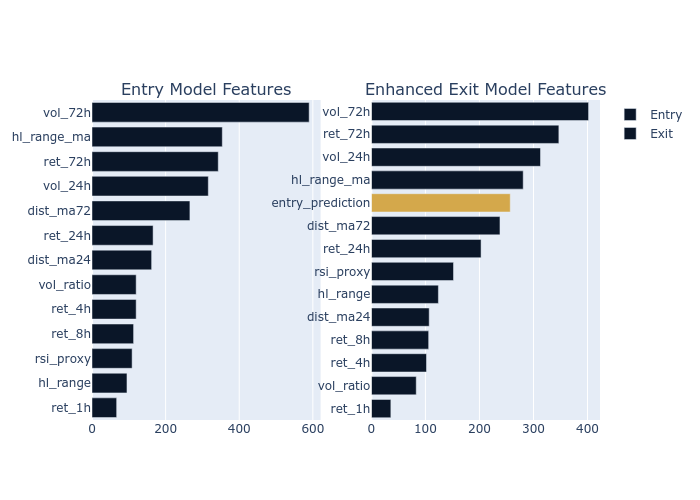

In [20]:
# Feature importance comparison
fig = make_subplots(
    rows=1, cols=2, subplot_titles=["Entry Model Features", "Enhanced Exit Model Features"]
)

# Entry model
entry_imp_sorted = entry_importance.sort_values("importance", ascending=True)
fig.add_trace(
    go.Bar(
        x=entry_imp_sorted["importance"],
        y=entry_imp_sorted["feature"],
        orientation="h",
        marker_color="#0a1628",
        name="Entry",
    ),
    row=1,
    col=1,
)

# Exit model
exit_imp_sorted = enhanced_importance.sort_values("importance", ascending=True)
colors = ["#D4A84B" if f == "entry_prediction" else "#0a1628" for f in exit_imp_sorted["feature"]]
fig.add_trace(
    go.Bar(
        x=exit_imp_sorted["importance"],
        y=exit_imp_sorted["feature"],
        orientation="h",
        marker_color=colors,
        name="Exit",
    ),
    row=1,
    col=2,
)

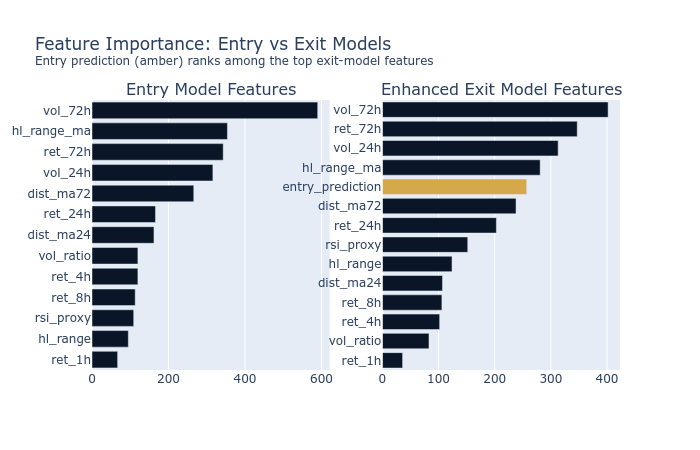

In [21]:
fig.update_layout(
    title="Feature Importance: Entry vs Exit Models<br><sup>Entry prediction (amber) ranks among the top exit-model features</sup>",
    height=450,
    showlegend=False,
)
fig.show()

**Interpretation**: `entry_prediction` (amber) ranks among the top exit-model
features, alongside the dominant volatility signals. The exit model uses fading
conviction even though that use does not lift AUC over the basic baseline.

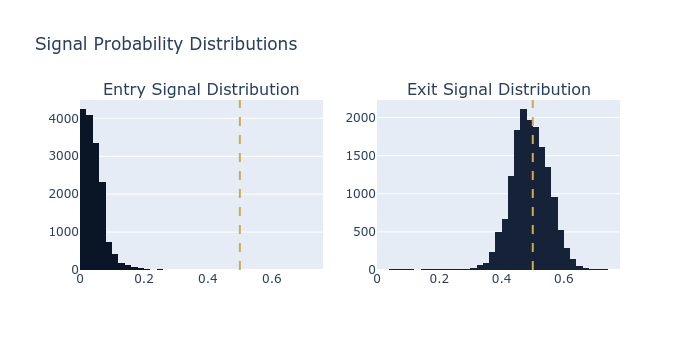

In [22]:
# Signal distribution
fig = make_subplots(
    rows=1, cols=2, subplot_titles=["Entry Signal Distribution", "Exit Signal Distribution"]
)

fig.add_trace(
    go.Histogram(x=entry_proba_test, nbinsx=50, name="Entry Prob", marker_color="#0a1628"),
    row=1,
    col=1,
)
fig.add_vline(x=entry_threshold, line_dash="dash", line_color="#D4A84B", row=1, col=1)

fig.add_trace(
    go.Histogram(x=exit_proba_enhanced, nbinsx=50, name="Exit Prob", marker_color="#152238"),
    row=1,
    col=2,
)
fig.add_vline(x=exit_threshold, line_dash="dash", line_color="#D4A84B", row=1, col=2)

fig.update_layout(
    title="Signal Probability Distributions",
    height=350,
    showlegend=False,
)
fig.show()

**Interpretation**: The probability histograms show whether the thresholds separate
high-conviction and low-conviction states cleanly enough to be used as trading rules.

In [23]:
publication_df = pd.DataFrame(
    {
        "signal": entry_proba_test,
        "fwd_return": test_df["fwd_return"].to_numpy(),
    }
)
publication_df["signal_quintile"] = pd.qcut(
    publication_df["signal"],
    q=5,
    labels=["Q1 (Weak)", "Q2", "Q3", "Q4", "Q5 (Strong)"],
)
publication_df["outcome"] = np.where(
    publication_df["fwd_return"] < 0,
    "Adverse move",
    np.where(publication_df["fwd_return"] >= top_5pct_threshold, "Strong upside", "Neutral"),
)
plot_data = (
    publication_df.groupby(["signal_quintile", "outcome"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(["Q1 (Weak)", "Q2", "Q3", "Q4", "Q5 (Strong)"])
)
plot_data = plot_data.div(plot_data.sum(axis=1), axis=0).mul(100.0).fillna(0.0)

# Persist quintile-conditioned outcome shares for the figure-19.5 publication script.
pl.from_pandas(plot_data.reset_index()).write_parquet(
    OUTPUT_DIR / "signal_quintile_outcomes.parquet"
)

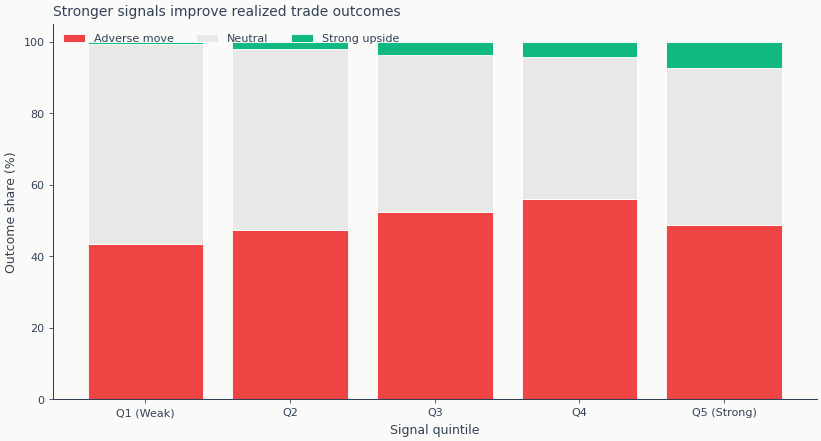

In [24]:
fig_pub, ax_pub = plt.subplots(figsize=(8.2, 4.4), constrained_layout=True)
bottom = np.zeros(len(plot_data))
for label, color in zip(
    ["Adverse move", "Neutral", "Strong upside"],
    [COLORS["negative"], COLORS["silver_muted"], COLORS["positive"]],
    strict=False,
):
    values = plot_data[label].to_numpy()
    ax_pub.bar(
        plot_data.index,
        values,
        bottom=bottom,
        label=label,
        color=color,
        edgecolor="white",
        linewidth=0.6,
    )
    bottom = bottom + values
ax_pub.set_ylabel("Outcome share (%)")
ax_pub.set_xlabel("Signal quintile")
ax_pub.set_title("Stronger signals improve realized trade outcomes")
ax_pub.legend(loc="upper left", ncols=3)
plt.show()

**Interpretation**: Bucketing test bars by entry-probability quintile shows
that the share of *strong-upside* outcomes rises monotonically from 0.6% in
the weakest quintile to 7.4% in the strongest. The *adverse-move* share is
roughly flat (it drifts up through Q4 then dips at Q5), so the lift comes
from **upside selection**, not from avoiding adverse moves. The conditioning
is real even though the basic exit model's AUC does not capture it: the
chapter's framing in §19.7 — judge exit logic by realized trade paths, not
by classification scores — is exactly what this figure illustrates.

## 12. Key Takeaways

In [25]:
takeaways = pl.DataFrame(
    {
        "Metric": [
            "Entry AUC",
            "Exit AUC (basic)",
            "Exit AUC (enhanced)",
            "AUC delta (enhanced − basic)",
            "Confidence-drop rule firing rate",
        ],
        "Value": [
            f"{entry_auc:.3f}",
            f"{exit_auc_basic:.3f}",
            f"{exit_auc_enhanced:.3f}",
            f"{(exit_auc_enhanced - exit_auc_basic):+.3f} ({improvement:+.2f}%)",
            f"{exit_signal_confidence.mean():.1%} of bars",
        ],
    }
)
takeaways

Metric,Value
str,str
"""Entry AUC""","""0.691"""
"""Exit AUC (basic)""","""0.487"""
"""Exit AUC (enhanced)""","""0.494"""
"""AUC delta (enhanced − basic)""","""+0.007 (+1.45%)"""
"""Confidence-drop rule firing ra…","""99.8% of bars"""


1. **Entry-conviction is informative for the exit model.** `entry_prediction`
   ranks among the top features of the enhanced exit model, yet the enhanced
   and basic exit AUCs are nearly identical (0.494 vs 0.487, both at the
   no-skill line) on this sample (see the table above). AUC is the wrong
   scoreboard for this kind of architectural change.
2. **Realized trade paths are the binding evaluation.** The Section-10 backtest
   separates the exit rules where AUC does not: the enhanced exit keeps the basic
   win rate while lifting Sharpe, the confidence-drop clause fires on the
   overwhelming majority of bars and chops every position to a few holding-bars,
   and the combined-OR rule inherits that aggression. Position-level controls have
   to be judged operationally (§19.7).
3. **Signal-strength conditioning is the durable lesson.** Figure 19.5 shows the
   fraction of adverse moves declining and the fraction of strong upside rising as
   entry-probability climbs. Even when AUC for the exit model is silent, this
   conditioning is real and exploitable.
4. **Implementation pattern.** Train entry and exit on the same feature set; pass
   the entry prediction to the exit model as an extra feature; use only lagged
   information so the feedback loop is causal.

**Next**: [`11_systematic_risk_sweep`](11_systematic_risk_sweep.ipynb) compares
these adaptive exits to parameterized rule sweeps and MAE/MFE-calibrated stops
(Figures 19.6–19.8, §19.7).